测试股票并集：421 只。
[GAN-GRU测试] [1/2] 开始滚动基础指标评价...
[BigQuant loader] 5/5（100.00%），依赖数据加载完成，当前 volume_ratio_5d，450,322 行，耗时 3.1s                                                                                                                            
[gan_gru_score] 特征计算 5/5，当前 volume_ratio_5d，耗时 1.8s                                                                                                                                                     
[GAN-GRU训练] 加载特征 5/5，当前 volume_ratio_5d，独立预热 4 日，耗时 1.4s                                                                                                                                     
[GAN-GRU训练] 未来收益标签构造完成 | 49,605/49,605 (100.0%) | 预计剩余 0.0s | 完整标签 49,605 条 | 已耗时 0.1s                                                                                                       
[GAN-GRU训练] 时序训练样本构造完成 | 397/397 (100.0%) | 预计剩余 0.0s | 有效样本 49,026 条 | 已耗时 2.3s                                                                                            

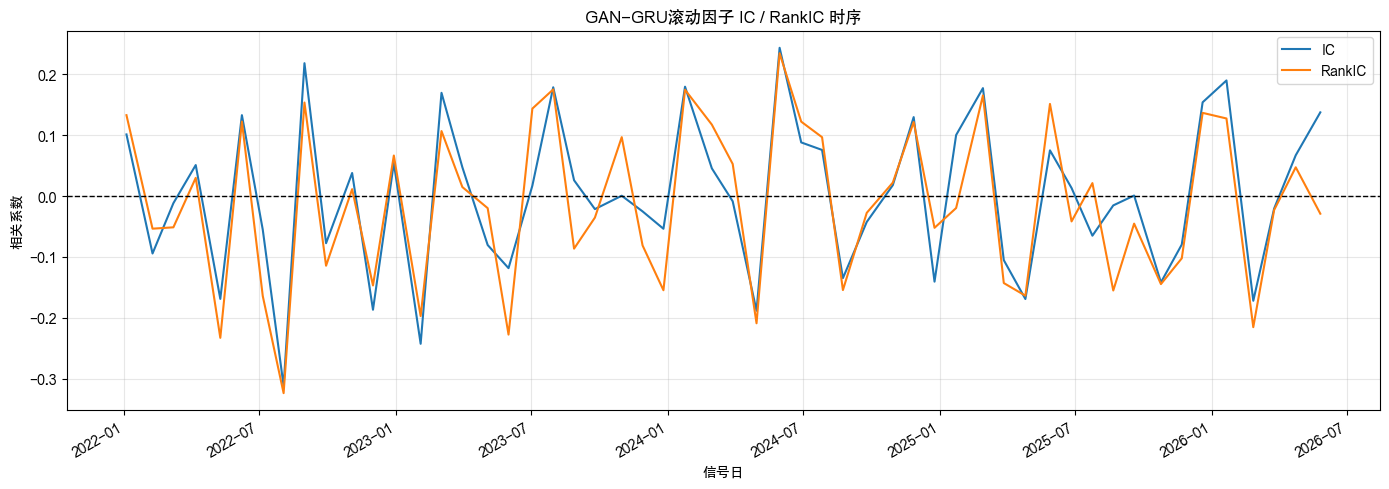


评价任务首次目标截面/首次训练锚点： 2022-01-04 00:00:00


,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,gan_gru_score,-0.000087,-0.000694,-0.014286,-0.107761,0.000465,-0.00383,54,54


,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
49,2026-01-20,2026-02-25,410,0.189570,0.127196,0.021034,3.899837
50,2026-02-25,2026-03-25,414,-0.171827,-0.215086,-0.019099,-3.540370
51,2026-03-25,2026-04-23,415,-0.020539,-0.022915,-0.002168,-0.417496
52,2026-04-23,2026-05-26,417,0.066842,0.047134,0.011099,1.364730
53,2026-05-26,2026-06-24,417,0.137234,-0.028988,0.018066,2.822363


[GAN-GRU测试] [2/2] 开始滚动市值分组回测...
[BigQuant loader] 5/5（100.00%），依赖数据加载完成，当前 volume_ratio_5d，458,684 行，耗时 2.8s                                                                                                                                                
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 22,863 行 | 已耗时 1.9s                                                                                                                                                        
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 22,863 行 | 已耗时 1.8s                                                                                                                                                        
[市值分组回测] [6/8] 启动 BigTrader 原生回测 | 0/55 (0.0%) | 55个信号，421只候选股票 | 已耗时 9.2s                                                                                                                                                  
[2026-08-10 16:35:13] [info     ] bigtrader.v35 开始运行 ..
[2026-08-10 16:35:14] [info 

[2026-08-10 16:38:21] [info     ] bigtrader.v35 运行完成 [187.183s].
[市值分组回测] [8/8] 回测与审计结果整理完成 | 1/1 (100.0%) | 信号1,650条，订单5,578条，成交2,789条 | 已耗时 196.8s                                                                                                                                         
策略首次训练锚点（首个信号日）： 2021-12-31 00:00:00
策略首次执行日： 2022-01-04 00:00:00


In [1]:
# -*- coding: utf-8 -*-
"""GAN-GRU 滚动训练模式：基础指标与市值分组回测功能测试。"""

import copy
import sys
from importlib import import_module

import dai
from IPython.display import display

from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)
from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)


sys.dont_write_bytecode = True


# =============================================================================
# 1. 测试区间
# =============================================================================

START_DATE = "2022-01-02"
END_DATE = "2026-06-30"

EVALUATION_FREQUENCY = 20
REBALANCE_INTERVAL = 20


# =============================================================================
# 2. 导入机器学习因子脚本中的模型状态提供器
# =============================================================================

# “Factor Repository”目录名包含空格，因此使用 import_module 动态导入。
gan_gru_module = import_module(
    "factor_lib.Factor Repository.gan_gru_score"
)


# =============================================================================
# 3. 功能测试使用的特征和训练参数
# =============================================================================

# 这里只选择5个基础特征，并减少训练轮数，目的是较快验证完整调用链：
# loader -> 基础因子 -> 滚动训练 -> 模型推理 -> 评价/策略。
# 它不是正式研究参数。正式研究时可以把 FEATURE_SPEC 改成 None，
# 并把 TRAINING_CONFIG 改为 None，以使用脚本中的模型4默认设置。
FEATURE_SPEC = [
    {
        "factor_name": "return_nd",
        "params": {"window": 1},
        "feature_name": "return_1d",
    },
    {
        "factor_name": "return_nd",
        "params": {"window": 5},
        "feature_name": "return_5d",
    },
    {
        "factor_name": "price_ma_distance_nd",
        "params": {"window": 10},
        "feature_name": "price_ma_distance_10d",
    },
    {
        "factor_name": "return_std_nd",
        "params": {"window": 10},
        "feature_name": "return_std_10d",
    },
    {
        "factor_name": "volume_ratio_nd",
        "params": {"window": 5},
        "feature_name": "volume_ratio_5d",
    },
]

TRAINING_CONFIG = {
    "sequence_length": 20,
    "training_window_days": 126,
    "retrain_interval_days": 84,
    "label_horizon_days": 5,
    "validation_ratio": 0.20,
    "purge_trading_days": 5,
    "minimum_validation_dates": 10,
    "minimum_rankic_stocks": 30,
    "minimum_training_samples": 1000,
    "latent_dim": 5,
    "discriminator_hidden_size": 16,
    "lambda_reconstruction": 0.5,
    "gan_epochs": 1,
    "gru_max_epochs": 3,
    "early_stop_patience": 2,
    "rankic_min_delta": 0.0001,
    "batch_size": 512,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "gan_learning_rate": 0.0002,
    "gru_learning_rate": 0.001,
    "random_seed": 42,
}


# =============================================================================
# 4. 为评价函数准备一个规模适中的静态测试股票列表
# =============================================================================

# 基础评价函数目前接收静态 instruments，因此这里使用测试区间内曾经属于
# 沪深300的股票并集，避免直接对全部A股执行多次神经网络训练。
universe_sql = f"""
SELECT DISTINCT instrument
FROM cn_stock_prefactors
WHERE date BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND is_hs300 = 1
ORDER BY instrument
"""

universe_data = dai.query(
    universe_sql,
    filters={"date": [START_DATE, END_DATE]},
).df()

if universe_data.empty:
    raise ValueError("未读取到沪深300历史成分股，无法开始测试。")

TEST_INSTRUMENTS = sorted(
    universe_data["instrument"].dropna().astype(str).unique().tolist()
)

print(f"测试股票并集：{len(TEST_INSTRUMENTS):,} 只。")


# =============================================================================
# 5. 基础指标评价：使用独立的内存模型状态提供器
# =============================================================================

# 提供器第一次收到评价目标日时会立即训练一次；该目标日就是评价任务的
# 首次训练锚点。之后每经过84个交易日才会再次训练。
evaluation_model_provider = gan_gru_module.build_model_state_provider(
    persistence_mode="memory",
)

evaluation_factor_params = {
    "feature_spec": copy.deepcopy(FEATURE_SPEC),
    "model_state_provider": evaluation_model_provider,
    "training_config": (
        None if TRAINING_CONFIG is None else dict(TRAINING_CONFIG)
    ),
}

print("[GAN-GRU测试] [1/2] 开始滚动基础指标评价...")

evaluation_result = calculate_factor_basic_metrics(
    start_date=START_DATE,
    end_date=END_DATE,
    frequency=EVALUATION_FREQUENCY,
    factor_name="gan_gru_score",
    factor_params=evaluation_factor_params,
    instruments=TEST_INSTRUMENTS,
    min_obs=30,
    plot=True,
    plot_title="GAN-GRU滚动因子 IC / RankIC 时序",
    figsize=(14, 5),
    show_progress=True,
    progress_every=5,
)

first_evaluation_target = evaluation_result[
    "evaluation_schedule"
]["date"].min()

print(
    "评价任务首次目标截面/首次训练锚点：",
    first_evaluation_target,
)
display(evaluation_result["summary"])
display(evaluation_result["timeseries"].tail())


# =============================================================================
# 6. 市值分组回测：重新建立独立的模型状态提供器
# =============================================================================

# 不能复用 evaluation_model_provider。否则回测会继承评价阶段已经训练好的
# 内存模型，首次信号日可能不会重新训练，导致两个任务状态相互污染。
strategy_model_provider = gan_gru_module.build_model_state_provider(
    persistence_mode="memory",
)

strategy_factor_params = {
    "feature_spec": copy.deepcopy(FEATURE_SPEC),
    "model_state_provider": strategy_model_provider,
    "training_config": (
        None if TRAINING_CONFIG is None else dict(TRAINING_CONFIG)
    ),
}

print("[GAN-GRU测试] [2/2] 开始滚动市值分组回测...")

backtest_result = run_market_cap_group_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,
    universe={
        "type": "index",
        "index_codes": ["000300.SH"],
    },
    factor_name="gan_gru_score",
    market_cap_group_count=15,
    selected_market_cap_groups=list(range(1, 16)),
    # gan_gru_score 数值越大，模型预测的未来收益越高，因此测试最高10%。
    factor_quantile_range=(0.9, 1.0),
    factor_params=strategy_factor_params,
    order_price_field_buy="open",
    order_price_field_sell="open",
    initial_cash=1_000_000,
    benchmark="000300.SH",
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },
    slippage_value=0.001,
    volume_limit=0.025,
    weight_tolerance=1e-4,
    show_progress=True,
    progress_every=5,
)

first_schedule_row = backtest_result["schedule"].iloc[0]
print(
    "策略首次训练锚点（首个信号日）：",
    first_schedule_row["signal_date"],
)
print(
    "策略首次执行日：",
    first_schedule_row["execution_date"],
)

# BigTrader 的回测图表会在 run_market_cap_group_backtest 执行时显示。
# 如需进一步检查，可按需取消下面代码的注释：
# display(backtest_result["data_diagnostics"])
# display(backtest_result["rebalance_audit"].head())
# display(backtest_result["trade_audit"].head())


[GAN-GRU 正式测试] 使用完整基础特征数： 20
[GAN-GRU 正式测试] 训练参数： {'sequence_length': 40, 'training_window_days': 336, 'retrain_interval_days': 84, 'label_horizon_days': 5, 'validation_ratio': 0.2, 'purge_trading_days': 5, 'minimum_validation_dates': 20, 'minimum_rankic_stocks': 30, 'minimum_training_samples': 1000, 'latent_dim': 10, 'discriminator_hidden_size': 32, 'lambda_reconstruction': 0.5, 'gan_epochs': 4, 'gru_max_epochs': 20, 'early_stop_patience': 4, 'rankic_min_delta': 0.0001, 'batch_size': 1024, 'cpu_threads': 4, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'gan_learning_rate': 0.0002, 'gru_learning_rate': 0.001, 'random_seed': 42}
[GAN-GRU 正式测试] 固定评价股票池：300 只，成分股截面日期：2023-05-04。
[GAN-GRU 正式测试] [1/2] 开始基础指标评价与时序图绘制...
[BigQuant loader] 20/20（100.00%），依赖数据加载完成，当前 volume_ratio_5d，107,700 行，耗时 4.7s                                                                                                                          
[gan_gru_score] 特征计算 20/20，当前 volume_ratio_5d，耗时 2.4s                

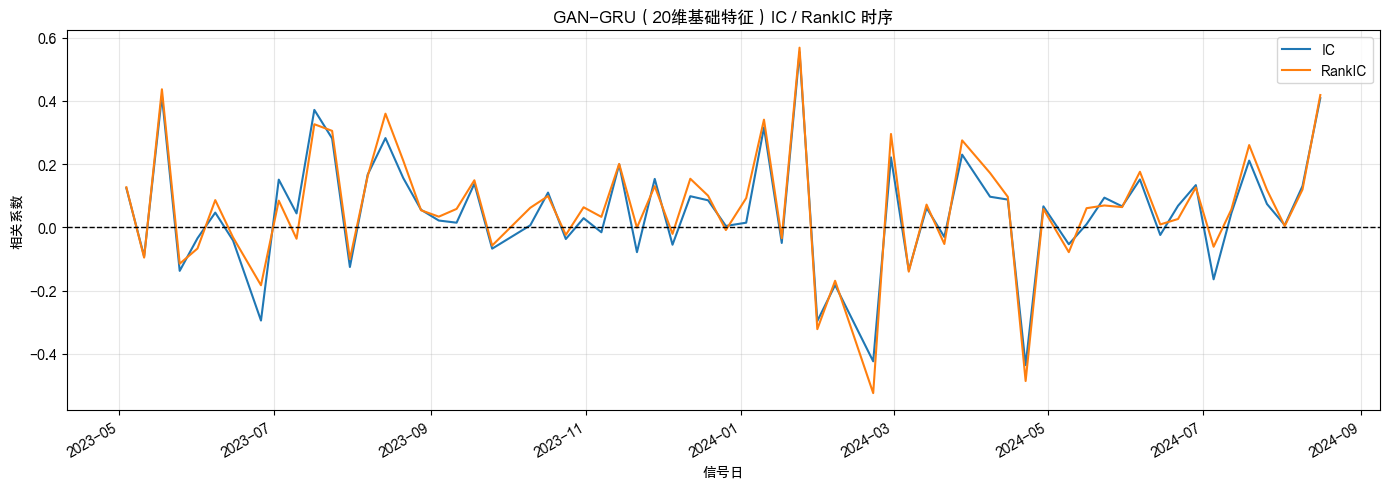


[GAN-GRU 正式测试] 有效评价截面数： 64


,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,gan_gru_score,0.050326,0.279775,0.064016,0.339138,0.001749,0.913595,64,64


,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
59,2024-07-19,2024-07-26,300,0.211028,0.260188,0.007567,3.726832
60,2024-07-26,2024-08-02,300,0.073811,0.118350,0.002617,1.277664
61,2024-08-02,2024-08-09,300,0.006815,0.004100,0.000236,0.117649
62,2024-08-09,2024-08-16,300,0.130511,0.119658,0.004045,2.272399
63,2024-08-16,2024-08-23,299,0.408818,0.418492,0.017349,7.720049


[GAN-GRU 正式测试] [2/2] 开始市值分组回测...
[BigQuant loader] 20/20（100.00%），依赖数据加载完成，当前 volume_ratio_5d，121,830 行，耗时 5.5s                                                                                                                                              
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 21,761 行 | 已耗时 1.5s                                                                                                                                                        
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 21,761 行 | 已耗时 1.3s                                                                                                                                                        
[市值分组回测] [6/8] 启动 BigTrader 原生回测 | 0/65 (0.0%) | 65个信号，335只候选股票 | 已耗时 12.4s                                                                                                                                                 
[2026-08-10 15:27:06] [info     ] bigtrader.v35 开始运行 ..
[2026-08-10 15:27:07] [info

[2026-08-10 16:21:49] [info     ] bigtrader.v35 运行完成 [3282.479s].
[市值分组回测] [8/8] 回测与审计结果整理完成 | 1/1 (100.0%) | 信号1,950条，订单5,930条，成交2,965条 | 已耗时 3295.1s                                                                                                                                        


In [1]:
# -*- coding: utf-8 -*-
"""GAN-GRU 20 维默认特征：基础指标与市值分组回测测试。

本脚本测试当前已经入库的 gan_gru_score 因子：
1. 使用脚本内 DEFAULT_FEATURE_SPEC 的完整 20 个基础因子；
2. 使用 DEFAULT_TRAINING_CONFIG 的正式训练参数；
3. 采用滚动训练模式，评价和回测各自使用独立的内存模型状态；
4. 用市值分组策略检验模型分数，不复刻研究稿中的指数权重偏移组合。
"""

import copy
import sys
from importlib import import_module

import dai
import pandas as pd
from IPython.display import display

from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)
from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)


sys.dont_write_bytecode = True


# =============================================================================
# 1. 研究与回测区间
# =============================================================================

# 该区间沿用研究稿的样例样本外区间。最末尾不足 5 个交易日的评价标签
# 会由基础指标函数自动剔除，不会使用未来收益。
START_DATE = "2022-05-02"
END_DATE = "2024-08-29"

# 原研究稿为周频调仓；这里以 5 个交易日作为因子评价和市值分组调仓频率。
EVALUATION_FREQUENCY = 5
REBALANCE_INTERVAL = 5

# 市值分组策略参数：只用于检验模型分数的选股能力，
# 不等同于研究稿中的沪深300指数权重偏移组合。
MARKET_CAP_GROUP_COUNT = 15
SELECTED_MARKET_CAP_GROUPS = list(range(1, MARKET_CAP_GROUP_COUNT + 1))
FACTOR_QUANTILE_RANGE = (0.9, 1.0)


# =============================================================================
# 2. 导入机器学习因子，并锁定完整 20 维特征和正式训练参数
# =============================================================================

gan_gru_module = import_module(
    "factor_lib.Factor Repository.gan_gru_score"
)

# None 虽然同样会使用默认特征，但这里显式复制默认列表，便于本次研究
# 固定并审计实际特征定义；不要在一次运行中修改该对象。
FEATURE_SPEC = copy.deepcopy(gan_gru_module.DEFAULT_FEATURE_SPEC)

# 显式复制当前因子脚本内的正式默认训练参数：40 日序列、336 日训练窗、
# 84 日更新间隔、未来 5 日标签、GAN 4 轮、GRU 最多 20 轮和 RankIC 早停。
TRAINING_CONFIG = copy.deepcopy(gan_gru_module.DEFAULT_TRAINING_CONFIG)

if len(FEATURE_SPEC) != 20:
    raise ValueError(
        "当前 GAN-GRU 默认特征数不是预期的 20 项；"
        "请检查 gan_gru_score.py 的 DEFAULT_FEATURE_SPEC。"
    )

print("[GAN-GRU 正式测试] 使用完整基础特征数：", len(FEATURE_SPEC))
print("[GAN-GRU 正式测试] 训练参数：", TRAINING_CONFIG)


# =============================================================================
# 3. 为因子基础指标准备无前视偏差的固定评价股票池
# =============================================================================

# 基础评价入口目前接收固定 instruments 列表。这里仅用研究期第一个可用
# 交易日的沪深300成分股建立该列表，避免使用后续日期才进入指数的股票。
# 市值分组回测则继续使用策略函数的动态历史指数成分股范围。
universe_sql = f"""
SELECT
    date,
    instrument
FROM cn_stock_prefactors
WHERE date BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND is_hs300 = 1
"""

universe_panel = dai.query(
    universe_sql,
    filters={"date": [START_DATE, END_DATE]},
).df()

if universe_panel.empty:
    raise ValueError("未读取到研究区间内的沪深300历史成分股。")

universe_panel["date"] = pd.to_datetime(universe_panel["date"])
first_universe_date = universe_panel["date"].min()

EVALUATION_INSTRUMENTS = sorted(
    universe_panel.loc[
        universe_panel["date"] == first_universe_date,
        "instrument",
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if not EVALUATION_INSTRUMENTS:
    raise ValueError("首个可用交易日没有沪深300成分股。")

EVALUATION_START_DATE = first_universe_date.strftime("%Y-%m-%d")

print(
    "[GAN-GRU 正式测试] 固定评价股票池："
    f"{len(EVALUATION_INSTRUMENTS):,} 只，"
    f"成分股截面日期：{EVALUATION_START_DATE}。"
)


# =============================================================================
# 4. 基础指标与 IC / RankIC 时序图
# =============================================================================

# 评价和策略必须使用彼此独立的状态提供器，防止前一阶段已训练的内存模型
# 影响后一阶段的首个训练锚点。
evaluation_model_provider = gan_gru_module.build_model_state_provider(
    persistence_mode="memory",
)

evaluation_factor_params = {
    "feature_spec": copy.deepcopy(FEATURE_SPEC),
    "model_state_provider": evaluation_model_provider,
    "training_config": copy.deepcopy(TRAINING_CONFIG),
}

print("[GAN-GRU 正式测试] [1/2] 开始基础指标评价与时序图绘制...")

evaluation_result = calculate_factor_basic_metrics(
    start_date=EVALUATION_START_DATE,
    end_date=END_DATE,
    frequency=EVALUATION_FREQUENCY,
    factor_name="gan_gru_score",
    factor_params=evaluation_factor_params,
    instruments=EVALUATION_INSTRUMENTS,
    min_obs=30,
    plot=True,
    plot_title="GAN-GRU（20维基础特征）IC / RankIC 时序",
    figsize=(14, 5),
    show_progress=True,
    progress_every=5,
)

print(
    "[GAN-GRU 正式测试] 有效评价截面数：",
    len(evaluation_result["timeseries"]),
)
display(evaluation_result["summary"])
display(evaluation_result["timeseries"].tail())


# =============================================================================
# 5. 市值分组回测
# =============================================================================

strategy_model_provider = gan_gru_module.build_model_state_provider(
    persistence_mode="memory",
)

strategy_factor_params = {
    "feature_spec": copy.deepcopy(FEATURE_SPEC),
    "model_state_provider": strategy_model_provider,
    "training_config": copy.deepcopy(TRAINING_CONFIG),
}

print("[GAN-GRU 正式测试] [2/2] 开始市值分组回测...")

backtest_result = run_market_cap_group_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,
    universe={
        "type": "index",
        "index_codes": ["000300.SH"],
    },
    factor_name="gan_gru_score",
    market_cap_group_count=MARKET_CAP_GROUP_COUNT,
    selected_market_cap_groups=SELECTED_MARKET_CAP_GROUPS,
    # 当前 gan_gru_score 数值越大表示预测未来收益越高，因此选最高 10%。
    factor_quantile_range=FACTOR_QUANTILE_RANGE,
    factor_params=strategy_factor_params,
    # 信号在 T 日收盘后形成，策略在下一个交易日开盘执行。
    order_price_field_buy="open",
    order_price_field_sell="open",
    initial_cash=1_000_000,
    benchmark="000300.SH",
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },
    slippage_value=0.001,
    volume_limit=0.025,
    weight_tolerance=1e-4,
    show_progress=True,
    progress_every=5,
)

# BigTrader 图表由 run_market_cap_group_backtest 在运行时展示。
# 如需检查审计信息，可按需取消以下注释：
# display(backtest_result["data_diagnostics"])
# display(backtest_result["rebalance_audit"].head())
# display(backtest_result["trade_audit"].head())


[GAN-GRU 全池选股测试] 基础特征数： 5
[GAN-GRU 全池选股测试] 训练参数： {'sequence_length': 20, 'training_window_days': 126, 'retrain_interval_days': 84, 'label_horizon_days': 20, 'validation_ratio': 0.2, 'purge_trading_days': 20, 'minimum_validation_dates': 10, 'minimum_rankic_stocks': 30, 'minimum_training_samples': 1000, 'latent_dim': 5, 'discriminator_hidden_size': 16, 'lambda_reconstruction': 0.5, 'gan_epochs': 1, 'gru_max_epochs': 3, 'early_stop_patience': 2, 'rankic_min_delta': 0.0001, 'batch_size': 512, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'gan_learning_rate': 0.0002, 'gru_learning_rate': 0.001, 'random_seed': 42}
[GAN-GRU 全池选股测试] 评价股票池：沪深300历史成分股并集，共 421 只。
[GAN-GRU 全池选股测试] [1/2] 开始基础指标评价与时序图绘制...
[BigQuant loader] 5/5（100.00%），依赖数据加载完成，当前 volume_ratio_5d，450,322 行，耗时 2.5s                                                                                                                            
[gan_gru_score] 特征计算 5/5，当前 volume_ratio_5d，耗时 1.6s                                        

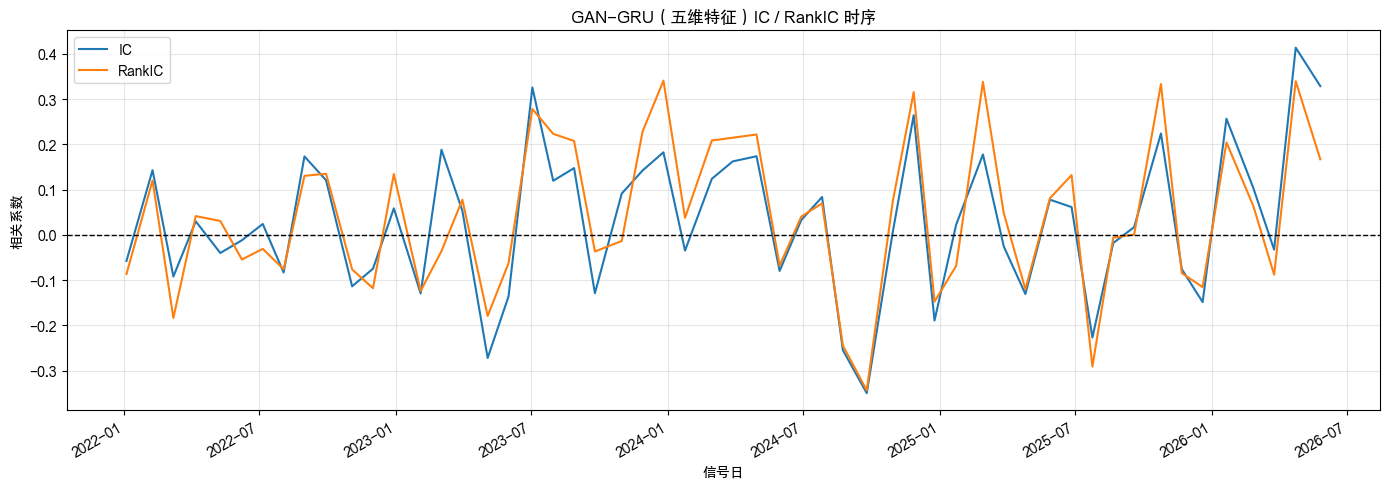


[GAN-GRU 全池选股测试] 有效评价截面数： 54


,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,gan_gru_score,0.029944,0.187239,0.040293,0.241068,0.002711,0.634625,54,54


,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
49,2026-01-20,2026-02-25,410,0.256500,0.204164,0.028461,5.360391
50,2026-02-25,2026-03-25,414,0.103691,0.063973,0.011526,2.116095
51,2026-03-25,2026-04-23,415,-0.032796,-0.088108,-0.003462,-0.666859
52,2026-04-23,2026-05-26,417,0.413565,0.339455,0.068671,9.253383
53,2026-05-26,2026-06-24,417,0.328552,0.166833,0.043252,7.086512


[GAN-GRU 全池选股测试] [2/2] 开始沪深300全池最高10%回测...
[BigQuant loader] 5/5（100.00%），依赖数据加载完成，当前 volume_ratio_5d，458,684 行，耗时 2.8s                                                                                                                                                
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 22,863 行 | 已耗时 1.7s                                                                                                                                                        
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 22,863 行 | 已耗时 1.7s                                                                                                                                                        
[市值分组回测] [6/8] 启动 BigTrader 原生回测 | 0/55 (0.0%) | 55个信号，421只候选股票 | 已耗时 8.9s                                                                                                                                                  
[2026-08-10 16:56:33] [info     ] bigtrader.v35 开始运行 ..
[2026-08-10 16:56

[2026-08-10 16:59:27] [info     ] bigtrader.v35 运行完成 [173.920s].
[市值分组回测] [8/8] 回测与审计结果整理完成 | 1/1 (100.0%) | 信号1,650条，订单5,614条，成交2,807条 | 已耗时 183.3s                                                                                                                                         


In [1]:
# -*- coding: utf-8 -*-
"""GAN-GRU 五维特征：沪深300全池最高分位选股测试。

用途：
1. 使用五个指定基础因子训练滚动 GAN-GRU；
2. 计算该机器学习因子的 IC / RankIC；
3. 在每个信号日的动态沪深300成分股中，直接买入原始分数最高的 10%。

说明：市值分组数设为 1，因此不再按市值分层。本脚本仍是等权多头
分位选股检验，而不是沪深300指数增强策略。
"""

import copy
import sys
from importlib import import_module

import dai
from IPython.display import display

from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)
from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)


sys.dont_write_bytecode = True


# =============================================================================
# 1. 研究、标签与调仓口径
# =============================================================================

START_DATE = "2022-01-02"
END_DATE = "2026-06-30"

# 本测试将模型训练标签、IC评价期限和策略调仓期限统一为 20 个交易日。
EVALUATION_FREQUENCY = 20
REBALANCE_INTERVAL = 20
LABEL_HORIZON_DAYS = 20

# 不按市值分层：整个动态沪深300是一个组，并从中选原始分数最高的10%。
MARKET_CAP_GROUP_COUNT = 1
SELECTED_MARKET_CAP_GROUPS = [1]
FACTOR_QUANTILE_RANGE = (0.9, 1.0)


# =============================================================================
# 2. 导入 GAN-GRU 因子模块
# =============================================================================

gan_gru_module = import_module(
    "factor_lib.Factor Repository.gan_gru_score"
)


# =============================================================================
# 3. 沿用功能测试中的五维基础特征
# =============================================================================

FEATURE_SPEC = [
    {
        "factor_name": "return_nd",
        "params": {"window": 1},
        "feature_name": "return_1d",
    },
    {
        "factor_name": "return_nd",
        "params": {"window": 5},
        "feature_name": "return_5d",
    },
    {
        "factor_name": "price_ma_distance_nd",
        "params": {"window": 10},
        "feature_name": "price_ma_distance_10d",
    },
    {
        "factor_name": "return_std_nd",
        "params": {"window": 10},
        "feature_name": "return_std_10d",
    },
    {
        "factor_name": "volume_ratio_nd",
        "params": {"window": 5},
        "feature_name": "volume_ratio_5d",
    },
]

# 沿用原功能测试的轻量网络与训练规模；仅将标签期限和 purge 间隔
# 对齐到 20 日，以对应本次 IC 评价和实际调仓持有期。
TRAINING_CONFIG = {
    "sequence_length": 20,
    "training_window_days": 126,
    "retrain_interval_days": 84,
    "label_horizon_days": LABEL_HORIZON_DAYS,
    "validation_ratio": 0.20,
    "purge_trading_days": LABEL_HORIZON_DAYS,
    "minimum_validation_dates": 10,
    "minimum_rankic_stocks": 30,
    "minimum_training_samples": 1000,
    "latent_dim": 5,
    "discriminator_hidden_size": 16,
    "lambda_reconstruction": 0.5,
    "gan_epochs": 1,
    "gru_max_epochs": 3,
    "early_stop_patience": 2,
    "rankic_min_delta": 0.0001,
    "batch_size": 512,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "gan_learning_rate": 0.0002,
    "gru_learning_rate": 0.001,
    "random_seed": 42,
}

print("[GAN-GRU 全池选股测试] 基础特征数：", len(FEATURE_SPEC))
print("[GAN-GRU 全池选股测试] 训练参数：", TRAINING_CONFIG)


# =============================================================================
# 4. 为基础评价准备沪深300历史成分股并集
# =============================================================================

# 基础评价函数当前接收静态 instruments；这里使用研究期内历史沪深300
# 成分股的并集。策略回测则会在每个信号日使用点时的动态历史成分股。
universe_sql = f"""
SELECT DISTINCT instrument
FROM cn_stock_prefactors
WHERE date BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND is_hs300 = 1
ORDER BY instrument
"""

universe_data = dai.query(
    universe_sql,
    filters={"date": [START_DATE, END_DATE]},
).df()

if universe_data.empty:
    raise ValueError("未读取到沪深300历史成分股，无法开始测试。")

EVALUATION_INSTRUMENTS = sorted(
    universe_data["instrument"].dropna().astype(str).unique().tolist()
)

print(
    "[GAN-GRU 全池选股测试] 评价股票池："
    f"沪深300历史成分股并集，共 {len(EVALUATION_INSTRUMENTS):,} 只。"
)


# =============================================================================
# 5. 基础指标与 IC / RankIC 时序
# =============================================================================

# 评价和回测必须使用独立状态提供器，避免前一阶段训练得到的内存模型
# 进入后一阶段，影响回测的首次训练与滚动更新时间线。
evaluation_model_provider = gan_gru_module.build_model_state_provider(
    persistence_mode="memory",
)

evaluation_factor_params = {
    "feature_spec": copy.deepcopy(FEATURE_SPEC),
    "model_state_provider": evaluation_model_provider,
    "training_config": copy.deepcopy(TRAINING_CONFIG),
}

print("[GAN-GRU 全池选股测试] [1/2] 开始基础指标评价与时序图绘制...")

evaluation_result = calculate_factor_basic_metrics(
    start_date=START_DATE,
    end_date=END_DATE,
    frequency=EVALUATION_FREQUENCY,
    factor_name="gan_gru_score",
    factor_params=evaluation_factor_params,
    instruments=EVALUATION_INSTRUMENTS,
    min_obs=30,
    plot=True,
    plot_title="GAN-GRU（五维特征）IC / RankIC 时序",
    figsize=(14, 5),
    show_progress=True,
    progress_every=1,
)

print(
    "[GAN-GRU 全池选股测试] 有效评价截面数：",
    len(evaluation_result["timeseries"]),
)
display(evaluation_result["summary"])
display(evaluation_result["timeseries"].tail())


# =============================================================================
# 6. 沪深300全池最高10%等权回测
# =============================================================================

strategy_model_provider = gan_gru_module.build_model_state_provider(
    persistence_mode="memory",
)

strategy_factor_params = {
    "feature_spec": copy.deepcopy(FEATURE_SPEC),
    "model_state_provider": strategy_model_provider,
    "training_config": copy.deepcopy(TRAINING_CONFIG),
}

print("[GAN-GRU 全池选股测试] [2/2] 开始沪深300全池最高10%回测...")

backtest_result = run_market_cap_group_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,
    universe={
        "type": "index",
        "index_codes": ["000300.SH"],
    },
    factor_name="gan_gru_score",
    market_cap_group_count=MARKET_CAP_GROUP_COUNT,
    selected_market_cap_groups=SELECTED_MARKET_CAP_GROUPS,
    # 策略按原始因子值从小到大排序；(0.9, 1.0) 表示选择最高10%。
    factor_quantile_range=FACTOR_QUANTILE_RANGE,
    factor_params=strategy_factor_params,
    order_price_field_buy="open",
    order_price_field_sell="open",
    initial_cash=1_000_000,
    benchmark="000300.SH",
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },
    slippage_value=0.001,
    volume_limit=0.025,
    weight_tolerance=1e-4,
    show_progress=True,
    progress_every=1,
)

# BigTrader 图表会在回测函数运行时自动展示。
# 仅在需要审计实际选股分位、调仓或成交限制时，取消以下注释：
# display(backtest_result["data_diagnostics"])
# display(backtest_result["rebalance_audit"].head())
# display(backtest_result["signals"]["factor_quantile"].describe())
# display(backtest_result["trade_audit"].head())
